In [1]:
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

from eeg.eeg_data import EEGLLM, EEGDataset, EEGLSTM, LSTMDataset
from eeg.eeg_data.datasets.utils import Colors

/root/eeg/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
eeg_dataset: EEGDataset = EEGDataset(region_tokenizer_path="../models/appendages", print_shapes=True)
lstm_dataset: LSTMDataset = LSTMDataset(region_tokenizer_path="../models/appendages", print_shapes=True)

Initializing dataset...
Getting VQVAE model...
Getting EEG data...
Filtered & processed EEG data.
Getting appendage data...
Retrieved appendage data.
Successful retrieved all data.
Pre-computing VQ-VAE tokens...


100%|██████████| 25/25 [00:04<00:00,  5.24it/s]


EEG shape:           (50583, 14)
app shape:           (50583, 12)
VQ-VAE tokens shape: (50583,)
total # of chunks: 44
Initializing dataset...
Getting VQVAE model...
Getting EEG data...
Filtered & processed EEG data.
Getting appendage data...
Retrieved appendage data.
Successful retrieved all data.
Pre-computing VQ-VAE tokens...


100%|██████████| 25/25 [00:02<00:00,  9.24it/s]

EEG shape:           (50583, 14)
app shape:           (50583, 12)
VQ-VAE tokens shape: (50583,)
total # of chunks: 44


In [11]:
def load_model(epoch: int, model_type: str = "llm") -> EEGLLM | EEGLSTM:
    if model_type == "llm":
        model = EEGLLM(
            vocab_size=512,
            num_layers=4,
            num_heads=4,
            num_channels=14,
            embedding_dim=64,
            ffn_hidden_dim=64,
            qk_length=64,
            value_length=64,
            max_length=2048,
            dropout=0.1
        )

        state_dict = torch.load(f"/var/log/thavamount/eeg_ckpts/eeg_lm/big/eeg_llm_epoch_{epoch}.pth", map_location="cpu")
        model.load_state_dict(state_dict["model"])

    elif model_type == "lstm":
        model = EEGLSTM(
            vocab_size=512,
            num_layers=8,
            num_channels=14,
            embedding_dim=128,
            dropout=0.1
        )

        state_dict = torch.load(f"/var/log/thavamount/eeg_ckpts/eeg_lm/lstm/eeg_lstm_epoch_{epoch}.pth", map_location="cpu")
        model.load_state_dict(state_dict["model"])
    
    return model

In [4]:
eeg, apps, tokens = eeg_dataset.get_val_data(0)
print(torch.Tensor(eeg).shape)
print(torch.Tensor(apps).shape)
print(torch.Tensor(tokens).shape)

torch.Size([900, 14])
torch.Size([900, 12])
torch.Size([900])


In [6]:
def inference(
    model: torch.nn.Module,
    eeg: torch.Tensor,
    tokens: torch.Tensor,
    run_num: int,
    seen_so_far: int = 100
) -> torch.Tensor:

    model.eval()

    eeg = eeg.unsqueeze(0).to(torch.int64)
    pred_tokens = [torch.tensor(i) for i in tokens[:seen_so_far].tolist()]

    print(f"{Colors.OKCYAN}Computing...{Colors.ENDC}")
    for i in tqdm(range(run_num)):
        token_logits  = model(eeg[:, :seen_so_far + i, :].to(torch.float32))

        best_token = torch.argmax(token_logits.squeeze(0)[-1])
        pred_tokens.append(best_token)

    return torch.stack(pred_tokens)  # (T, 1)

/tmp/ipykernel_51348/4227986869.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(tokens),


Computing...


100%|██████████| 200/200 [00:09<00:00, 20.36it/s]


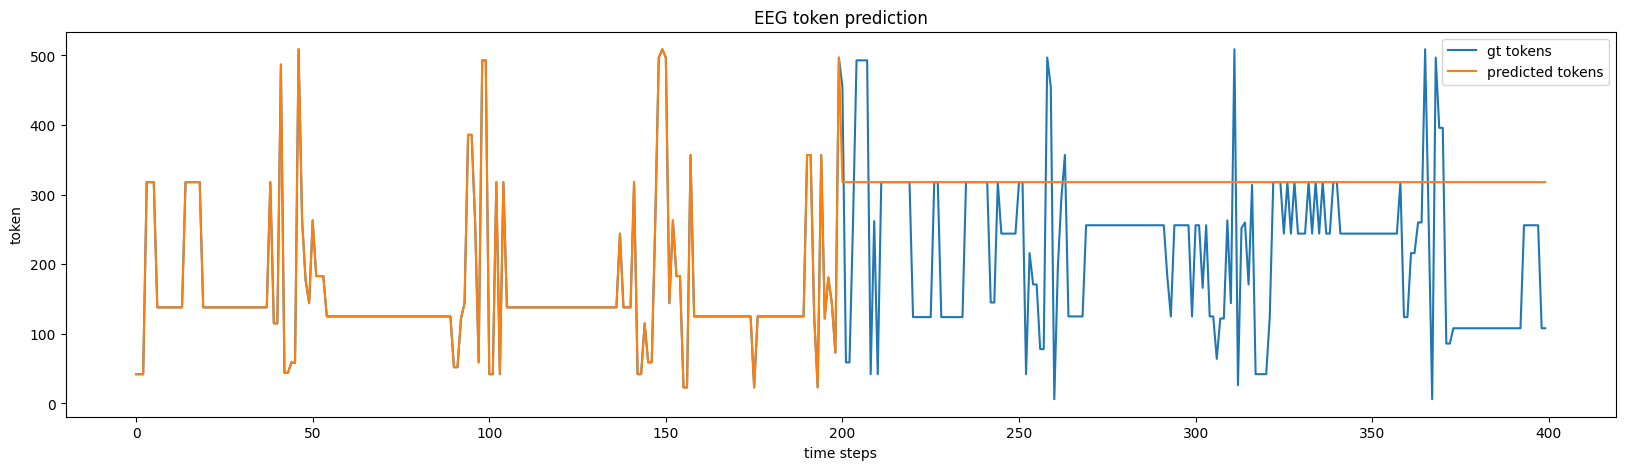

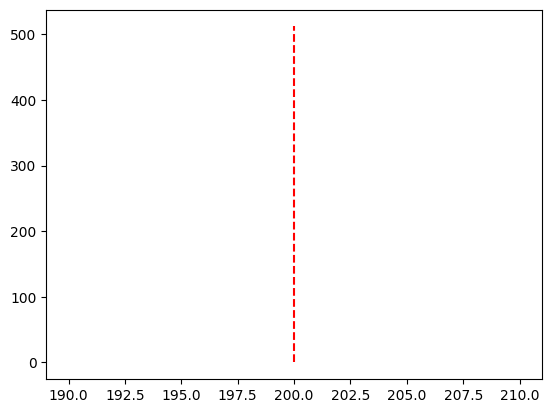

In [14]:
run_num = 200
seen_so_far = 200
model = load_model(epoch=500, model_type="lstm")
pred_tokens = inference(
    model,
    torch.Tensor(eeg),
    torch.tensor(tokens),
    run_num=run_num,
    seen_so_far=seen_so_far
)

plt.figure(figsize=(20, 5))
plt.plot(tokens[:run_num + seen_so_far], label="gt tokens")
plt.plot(pred_tokens.cpu().numpy(), label="predicted tokens")
plt.legend()
plt.title("EEG token prediction")
plt.xlabel("time steps")
plt.ylabel("token")
plt.vlines(x=seen_so_far, ymin=0, ymax=512, colors="red", linestyles="dashed", label="prediction start")
plt.show()